In [1]:
# ======== U-Net++ (UnetPlusPlus) with MobileNetV3 encoder - full script ========
# Keeps dataset / training flow and replaces the model with Unet++ (MobileNetV3 backbone)

# Install required library (uncomment if running in a fresh environment; Kaggle may already have it)
# !pip install -q segmentation-models-pytorch==0.3.8 timm
!pip install -q segmentation-models-pytorch==0.5.0 timm==0.9.12

import os, random, time
import numpy as np
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# segmentation_models_pytorch (SMP) import
import segmentation_models_pytorch as smp

# ----------------------- Config -----------------------
BASE_PATH = "/kaggle/input/landcover-images/landcover_images"  # adjust if needed
IMG_SIZE = 256
BATCH_SIZE = 4
LR = 1e-4
EPOCHS = 30
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = min(8, max(1, (os.cpu_count() or 2) // 2))
PIN_MEMORY = True

print("Device:", DEVICE)
print("Workers:", NUM_WORKERS)

# ----------------------- Utility: build mapping from train masks -----------------------
def create_mask_value_mapping(mask_dir):
    """Scan all mask files in mask_dir and build mapping {original_value: new_index} sorted."""
    values = set()
    for fname in sorted(os.listdir(mask_dir)):
        p = os.path.join(mask_dir, fname)
        # skip files that aren't images
        try:
            m = np.array(Image.open(p))
        except Exception:
            continue
        # if RGB, collapse to single channel (assuming palette or identical channels)
        if m.ndim == 3:
            # try to convert to grayscale indices if palette based
            # Convert by taking first channel
            m2 = m[..., 0]
            vals = np.unique(m2)
        else:
            vals = np.unique(m)
        values.update(vals.tolist())
    values = sorted([int(v) for v in values])
    mapping = {orig: i for i, orig in enumerate(values)}
    return mapping

train_mask_dir = os.path.join(BASE_PATH, "train/masks")
mask_value_to_index = create_mask_value_mapping(train_mask_dir)
NUM_CLASSES = len(mask_value_to_index)
print("Detected mask values mapping (original -> remapped):")
print(mask_value_to_index)
print("NUM_CLASSES:", NUM_CLASSES)

# ----------------------- Dataset -----------------------
class SegmentationDatasetRemap(Dataset):
    def __init__(self, image_dir, mask_dir, mask_mapping, img_size=256, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.images = sorted([f for f in os.listdir(image_dir) if not f.startswith('.')])
        self.masks = sorted([f for f in os.listdir(mask_dir) if not f.startswith('.')])
        self.mask_mapping = mask_mapping
        self.img_size = img_size
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_p = os.path.join(self.image_dir, self.images[idx])
        m_p   = os.path.join(self.mask_dir, self.masks[idx])

        image = Image.open(img_p).convert("RGB")
        mask  = Image.open(m_p)

        # Resize image and mask
        image = image.resize((self.img_size, self.img_size), Image.BILINEAR)
        mask  = mask.resize((self.img_size, self.img_size), Image.NEAREST)

        # Convert mask to numpy and remap values
        mask_np = np.array(mask)
        if mask_np.ndim == 3:
            # if RGB palette, collapse to single channel by taking first channel (common for paletted PNG)
            mask_np = mask_np[..., 0]

        # Map original values -> consecutive indices
        # Use vectorize with get to be safe for all values
        remap_func = np.vectorize(self.mask_mapping.get)
        mask_remapped = remap_func(mask_np)
        mask_remapped = mask_remapped.astype(np.int64)

        mask_tensor = torch.from_numpy(mask_remapped).long()

        if self.transform is not None:
            image = self.transform(image)
        else:
            image = transforms.ToTensor()(image)

        return image, mask_tensor

# ----------------------- Transforms -----------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ----------------------- Create datasets and loaders -----------------------
train_images = os.path.join(BASE_PATH, "train/images")
train_masks  = os.path.join(BASE_PATH, "train/masks")
val_images   = os.path.join(BASE_PATH, "validation/images")
val_masks    = os.path.join(BASE_PATH, "validation/masks")
test_images  = os.path.join(BASE_PATH, "test/images")
test_masks   = os.path.join(BASE_PATH, "test/masks")

train_dir = "/kaggle/input/landcover-images/landcover_images/train/images"
mask_dir = "/kaggle/input/landcover-images/landcover_images/train/masks"

val_dir = "/kaggle/input/landcover-images/landcover_images/validation/images"
val_mask_dir = "/kaggle/input/landcover-images/landcover_images/validation/masks"

test_dir = "/kaggle/input/landcover-images/landcover_images/test/images"
test_mask_dir = "/kaggle/input/landcover-images/landcover_images/test/masks"


train_ds = SegmentationDatasetRemap(train_images, train_masks, mask_value_to_index, IMG_SIZE, transform)
val_ds   = SegmentationDatasetRemap(val_images, val_masks, mask_value_to_index, IMG_SIZE, transform)
test_ds  = SegmentationDatasetRemap(test_images, test_masks, mask_value_to_index, IMG_SIZE, transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print(f"Train size: {len(train_ds)} | Val size: {len(val_ds)} | Test size: {len(test_ds)}")

# ----------------------- Model: Unet++ with MobileNetV3 encoder -----------------------
# Use SMP UnetPlusPlus. encoder_name 'mobilenet_v3_large' should be supported (timm-based)
encoder_name = "mobilenet_v2"
encoder_weights = "imagenet"          # pretrained weights

# Create Unet++ (Nested U-Net) model from SMP
model = smp.UnetPlusPlus(
    encoder_name=encoder_name,
    encoder_weights="imagenet",
    in_channels=3,
    classes=NUM_CLASSES,
)


model = model.to(DEVICE)
print("Model created:", model.__class__.__name__, "encoder:", encoder_name)

# ----------------------- Loss, optimizer, scheduler -----------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scaler = torch.cuda.amp.GradScaler()

# Optional scheduler (uncomment to use)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)

# ----------------------- Training loop with tqdm and best-model saving -----------------------
best_val_loss = float('inf')
patience = 5
epochs_no_improve = 0
best_model_path = "best_unetpp_mobilenetv3.pth"

train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    loop = tqdm(train_loader, total=len(train_loader), desc=f"Epoch {epoch}/{EPOCHS} - Train", leave=False)
    t0 = time.time()
    for images, masks in loop:
        images = images.to(DEVICE, non_blocking=True)
        masks  = masks.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            outputs = model(images)                 # outputs shape: (B, C, H, W)
            loss = criterion(outputs, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        loop.set_postfix(train_loss=loss.item())

    epoch_train_loss = running_loss / max(1, len(train_loader))
    train_losses.append(epoch_train_loss)

    # Validation
    model.eval()
    val_running = 0.0
    with torch.no_grad():
        vloop = tqdm(val_loader, total=len(val_loader), desc=f"Epoch {epoch}/{EPOCHS} - Val", leave=False)
        for images, masks in vloop:
            images = images.to(DEVICE, non_blocking=True)
            masks  = masks.to(DEVICE, non_blocking=True)
            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, masks)
            val_running += loss.item()
            vloop.set_postfix(val_loss=loss.item())

    epoch_val_loss = val_running / max(1, len(val_loader))
    val_losses.append(epoch_val_loss)

    elapsed = time.time() - t0
    print(f"Epoch [{epoch}/{EPOCHS}]  Train Loss: {epoch_train_loss:.6f}  Val Loss: {epoch_val_loss:.6f}  Time: {elapsed:.1f}s")

    # Scheduler step if using ReduceLROnPlateau
    # scheduler.step(epoch_val_loss)

    # Early stopping / save best model
    if epoch_val_loss < best_val_loss - 1e-6:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), best_model_path)
        print("  ✅ Best model saved.")
    else:
        epochs_no_improve += 1
        print(f"  No improvement epochs: {epochs_no_improve}/{patience}")
        if epochs_no_improve >= patience:
            print(f"  ⚠️ Early stopping triggered (no improvement for {patience} epochs).")
            break

print("Training finished. Best val loss:", best_val_loss)





/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

Device: cuda
Workers: 2
Detected mask values mapping (original -> remapped):
{0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8}
NUM_CLASSES: 9
Train size: 9968 | Val size: 1245 | Test size: 1249


/tmp/ipykernel_212/3783973722.py:167: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Model created: UnetPlusPlus encoder: mobilenet_v2


Epoch 1/30 - Train:   0%|          | 0/2492 [00:00<?, ?it/s]/tmp/ipykernel_212/3783973722.py:190: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/30 - Val:   0%|          | 0/312 [00:00<?, ?it/s]                                /tmp/ipykernel_212/3783973722.py:212: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

Epoch [18/30]  Train Loss: 0.666633  Val Loss: 0.704314  Time: 219.9s
  No improvement epochs: 1/5


Epoch [19/30]  Train Loss: 0.655997  Val Loss: 0.700296  Time: 221.0s
  No improvement epochs: 2/5


Epoch [20/30]  Train Loss: 0.649931  Val Loss: 0.689748  Time: 220.6s
  No improvement epochs: 3/5


Epoch [21/30]  Train Loss: 0.645479  Val Loss: 0.704984  Time: 220.4s
  No improvement epochs: 4/5


Epoch [22/30]  Train Loss: 0.633520  Val Loss: 0.705472  Time: 222.3s
  No improvement epochs: 5/5
  ⚠️ Early stopping triggered (no improvement for 5 epochs).
Training finished. Best val loss: 0.684552319204578


Loaded best model from best_unetpp_mobilenetv3.pth


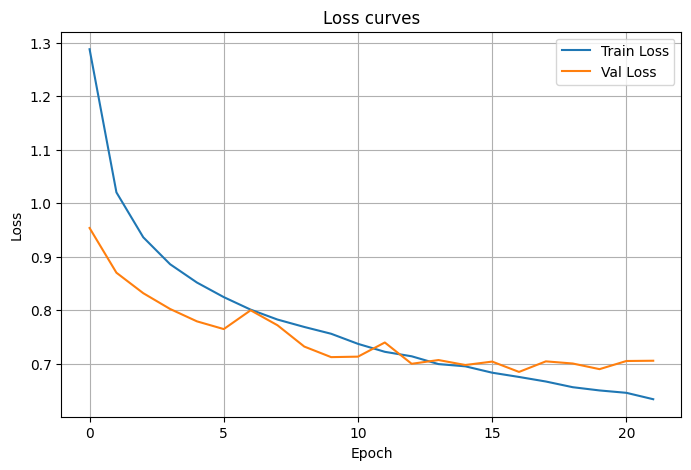

In [2]:
# ----------------------- Load best model -----------------------
if os.path.exists(best_model_path):
    model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
    print("Loaded best model from", best_model_path)
else:
    print("Best model not found, using last model state.")

# ----------------------- Plot loss curves -----------------------
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.title("Loss curves")
plt.show()

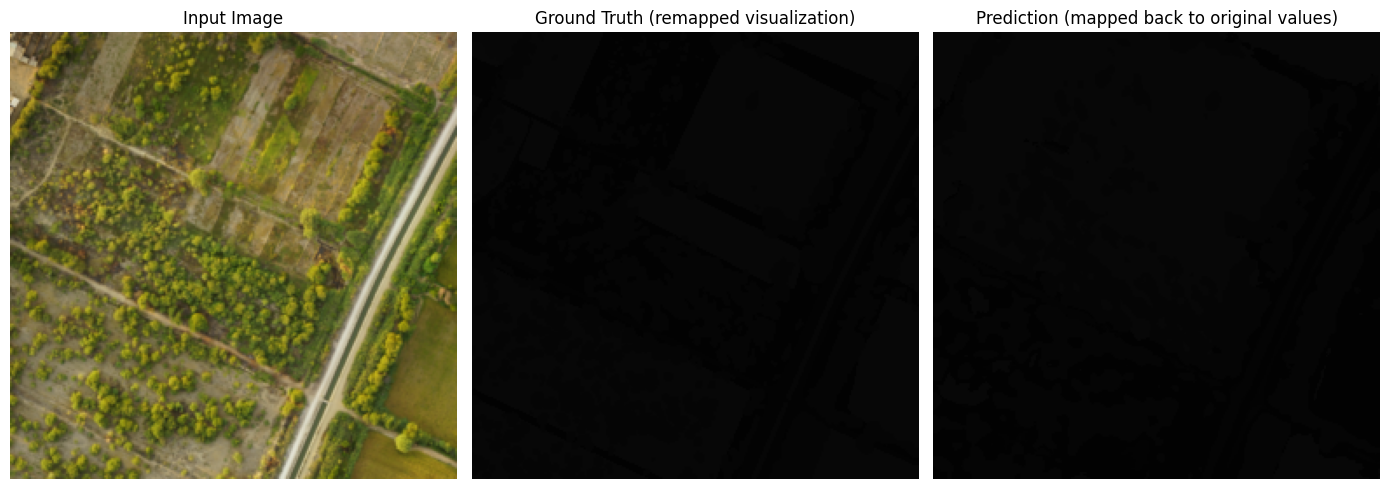

In [3]:
# ----------------------- Sample predictions (visualization) -----------------------
model.eval()
idx = random.randint(0, len(test_ds) - 1)
img_tensor, true_mask = test_ds[idx]

with torch.no_grad():
    out = model(img_tensor.unsqueeze(0).to(DEVICE))
pred_mask = torch.argmax(out.squeeze(0).cpu(), dim=0).numpy()  # H x W

# Map predicted indices back to original mask values (for visualization)
index_to_value = {v: k for k, v in mask_value_to_index.items()}
# create grayscale visualization where pixel intensity is original mask value (optional)
pred_vis = np.zeros((pred_mask.shape[0], pred_mask.shape[1], 3), dtype=np.uint8)
true_vis = np.zeros_like(pred_vis)
for idx_class, orig_val in index_to_value.items():
    pred_vis[pred_mask == idx_class] = [int(orig_val)] * 3
    true_vis[true_mask.numpy() == idx_class] = [int(orig_val)] * 3

plt.figure(figsize=(14,6))
plt.subplot(1,3,1)
plt.imshow((img_tensor.permute(1,2,0).numpy() * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])).clip(0,1))
plt.title("Input Image"); plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(true_vis)
plt.title("Ground Truth (remapped visualization)"); plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(pred_vis)
plt.title("Prediction (mapped back to original values)"); plt.axis('off')

plt.tight_layout()
plt.show()

# ================= End of script =================


In [6]:
import numpy as np

# pred_mask is already numpy
mask = np.squeeze(pred_mask)  # remove extra dimensions if any
print("Unique values in prediction:", np.unique(mask))


Unique values in prediction: [1 2 3 4 5 7 8]


In [8]:
import numpy as np

# Assuming pred_mask is your numpy prediction (H, W)
remap_dict = {1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 7: 5, 8: 6}
remapped_pred = np.zeros_like(pred_mask)

for old_val, new_val in remap_dict.items():
    remapped_pred[pred_mask == old_val] = new_val

print("Remapped unique values:", np.unique(remapped_pred))
colored_pred = plt.cm.get_cmap('tab20', len(np.unique(remapped_pred)))(remapped_pred)[..., :3]


Remapped unique values: [0 1 2 3 4 5 6]


/tmp/ipykernel_212/3240878332.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colored_pred = plt.cm.get_cmap('tab20', len(np.unique(remapped_pred)))(remapped_pred)[..., :3]


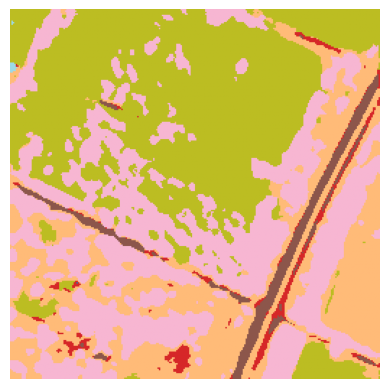

In [9]:
plt.imshow(colored_pred)
plt.axis('off')
plt.show()


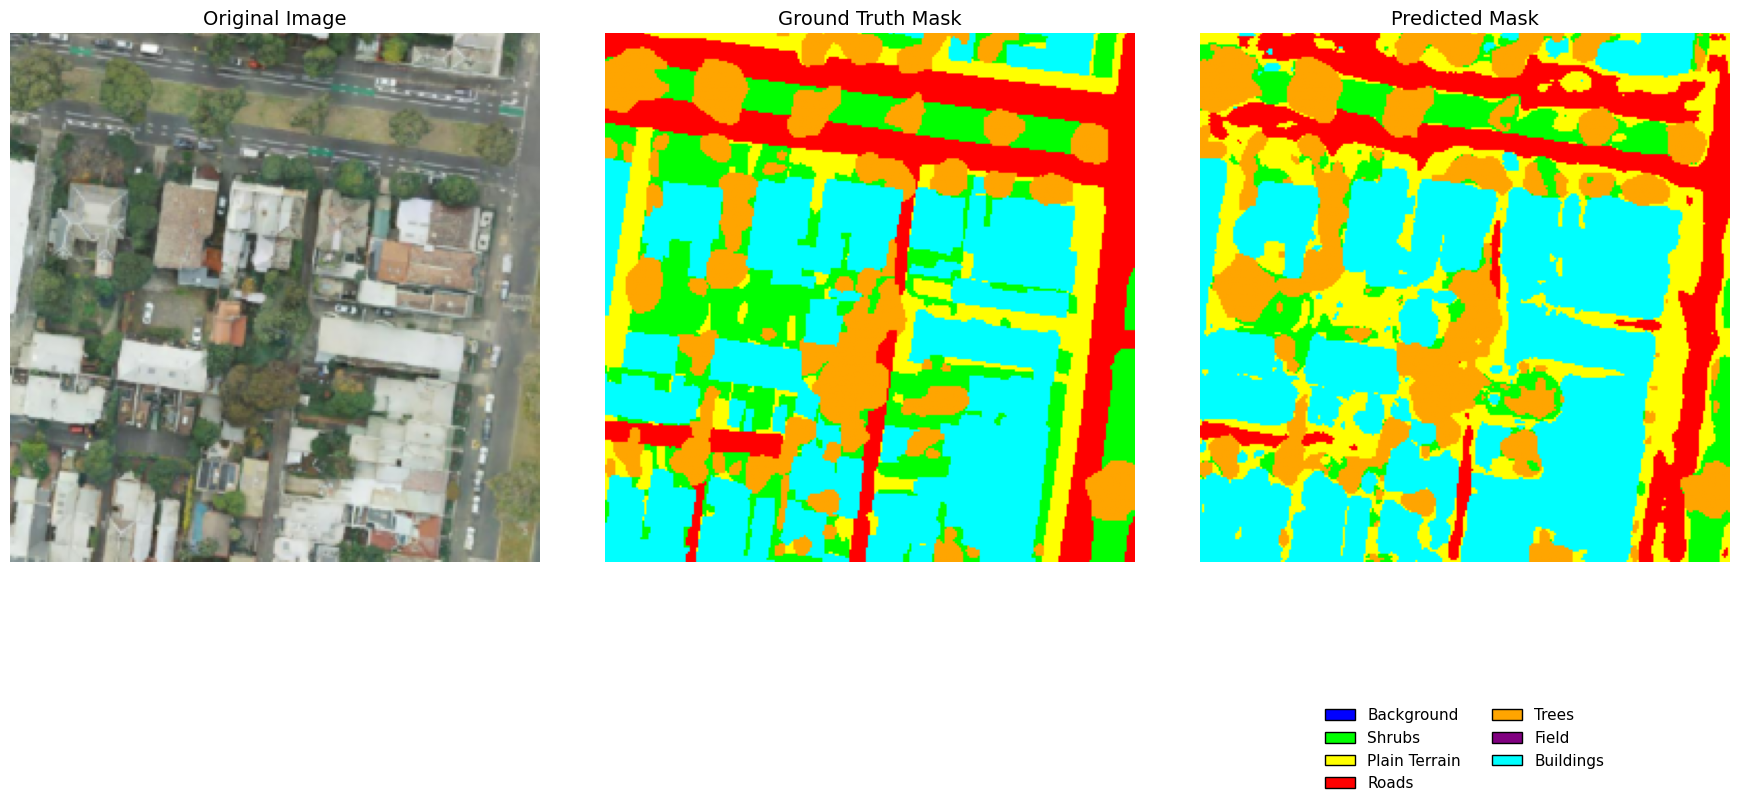

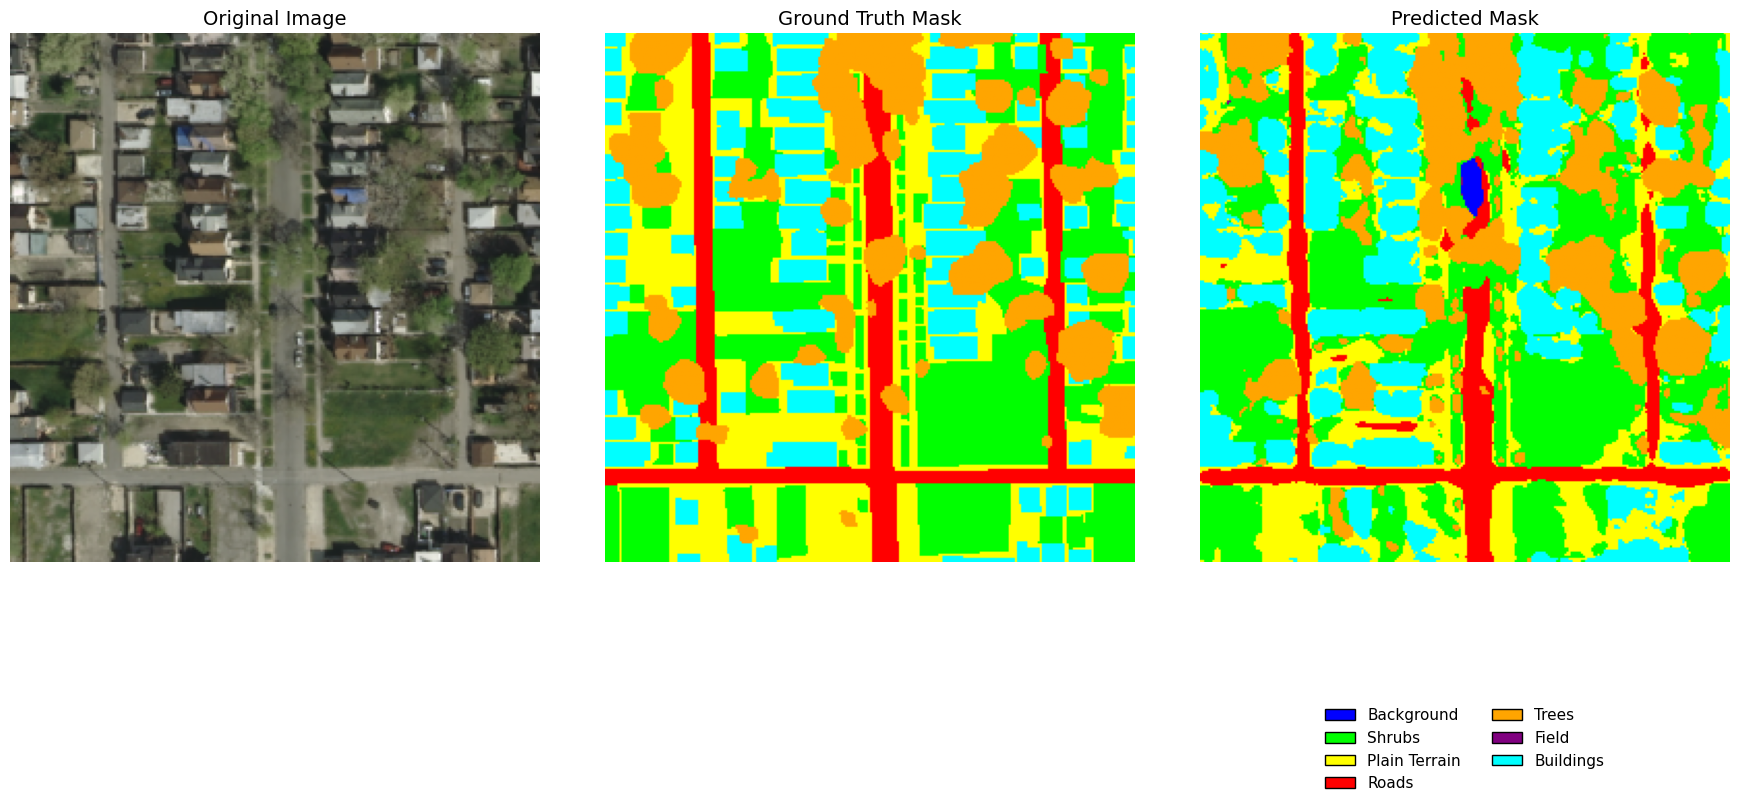

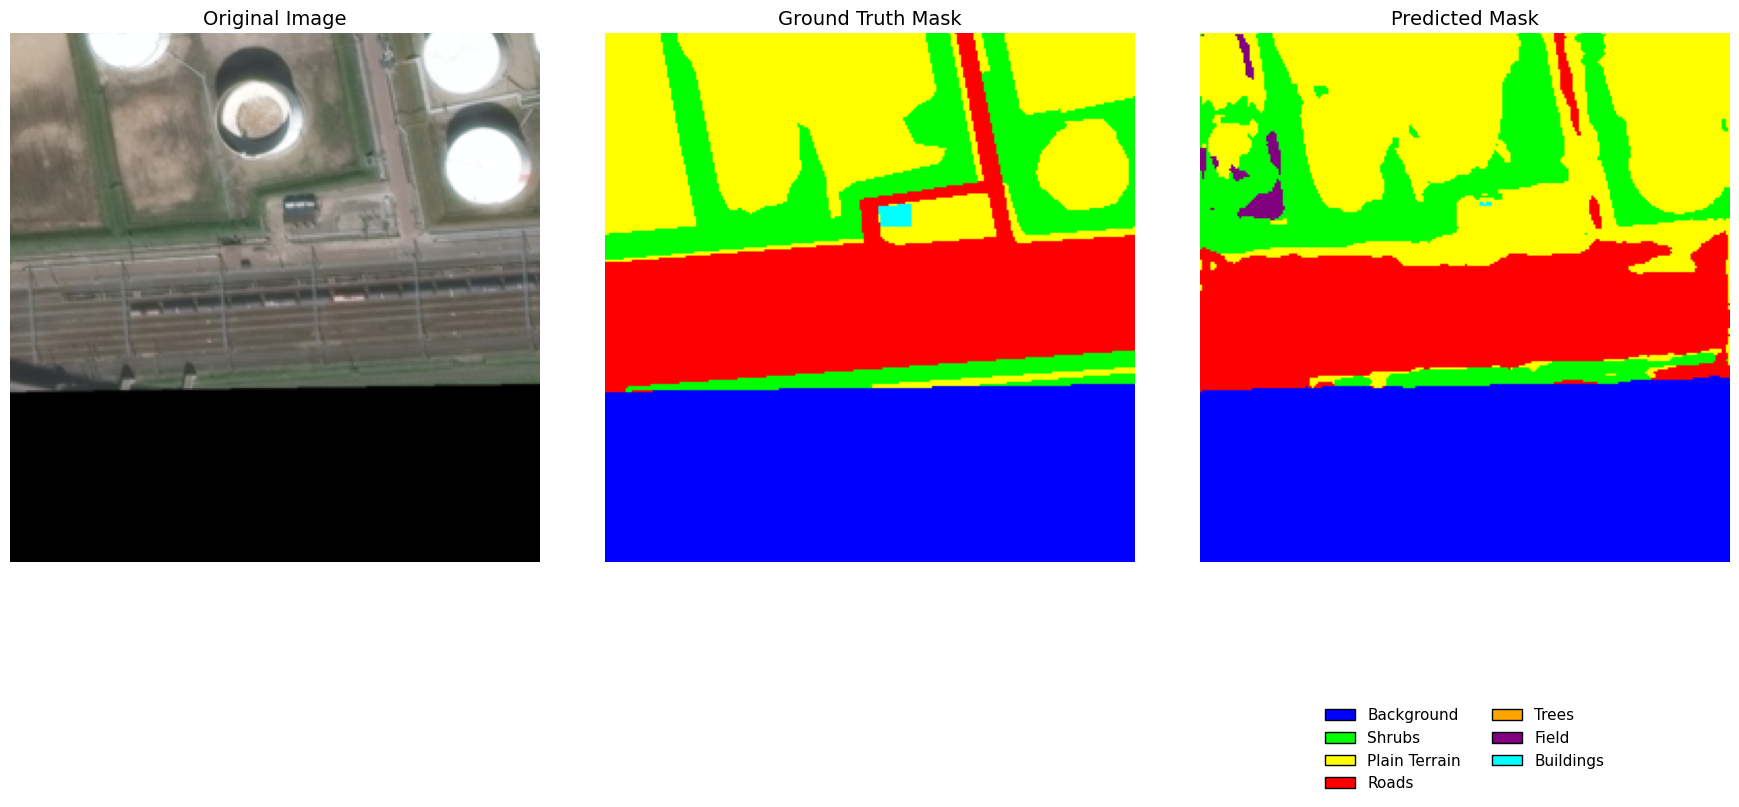

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch, random
from matplotlib.patches import Patch

# --- ImageNet normalization constants (for denormalizing) ---
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

# --- Vibrant consistent color palette ---
bright_colors = np.array([
    [0, 0, 255],      # Blue
    [0, 255, 0],      # Green
    [255, 255, 0],    # Yellow
    [255, 0, 0],      # Red
    [255, 165, 0],    # Orange
    [128, 0, 128],    # Purple
    [0, 255, 255]     # Cyan
]) / 255.0

# --- Corresponding class labels ---
class_labels = [
    "Background",  # Blue
    "Shrubs",       # Green
    "Plain Terrain",  # Yellow
    "Roads",       # Red
    "Trees",      # Orange
    "Field",       # Purple
    "Buildings"    # Cyan
]

cmap = mcolors.ListedColormap(bright_colors)

# --- Safe remap helper ---
def safe_remap(mask, remap_dict, default_val=0):
    vec = np.vectorize(lambda x: remap_dict.get(x, default_val))
    return vec(mask).astype(np.uint8)

# --- Visualization function ---
def visualize_prediction(image_tensor, true_mask, pred_mask, remap_dict, cmap):
    # Denormalize the image
    image = image_tensor.permute(1, 2, 0).cpu().numpy()
    image = (image * std + mean)
    image = np.clip(image, 0, 1)

    # Remap masks for consistent color
    remapped_true = safe_remap(true_mask, remap_dict)
    remapped_pred = safe_remap(pred_mask, remap_dict)

    # Apply consistent colors
    colored_true = cmap(remapped_true)[..., :3]
    colored_pred = cmap(remapped_pred)[..., :3]

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(18, 7))
    axes[0].imshow(image)
    axes[0].set_title("Original Image", fontsize=14)
    axes[0].axis("off")

    axes[1].imshow(colored_true)
    axes[1].set_title("Ground Truth Mask", fontsize=14)
    axes[1].axis("off")

    im = axes[2].imshow(colored_pred)
    axes[2].set_title("Predicted Mask", fontsize=14)
    axes[2].axis("off")

    # --- Legend only below predicted mask ---
    legend_elements = [
        Patch(facecolor=bright_colors[i], edgecolor='black', label=class_labels[i])
        for i in range(len(class_labels))
    ]

    # Add legend below predicted image
    axes[2].legend(
        handles=legend_elements,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.25),
        ncol=2,
        fontsize=11,
        frameon=False
    )

    plt.tight_layout()
    plt.show()


# --- Randomly sample 3 images for visualization ---
model.eval()
indices = random.sample(range(len(test_ds)), 3)

for i in indices:
    img_tensor, true_mask = test_ds[i]
    with torch.no_grad():
        output = model(img_tensor.unsqueeze(0).to(DEVICE))
        pred_mask = torch.argmax(output.squeeze(), dim=0).cpu().numpy()

    visualize_prediction(img_tensor, true_mask.numpy(), pred_mask, remap_dict, cmap)


In [34]:
torch.save(model.state_dict(), "/kaggle/working/resnet_model.pth")
print("✅ Model saved successfully!")

✅ Model saved successfully!


Pixels evaluated: 81592320

Confusion Matrix:
 [[  635282       26     1751     4075      449      838      445      474
      1061]
 [     769   768134   139337   237277     5735    10060    78732    34741
      7038]
 [    3195    76234 10899458  1322394   125298  2519544    72454  1804600
    348759]
 [    3686   156221  1469831  9244097  1142208   279312    23297   162259
   2438645]
 [    1117    12867   217499  1363415  3536260    79785    11071    57173
    124708]
 [    1294     2781  2651879   379623    63994 11401676    53419   332937
    129238]
 [    2527    33237   188877    58635    25109    67502  2191807    86380
     31254]
 [    1422    17159   976460   183737    17968   215467    15854  9566124
     16942]
 [     769      688   274292  1490723    65559    83089     3203    22871
  11516213]]


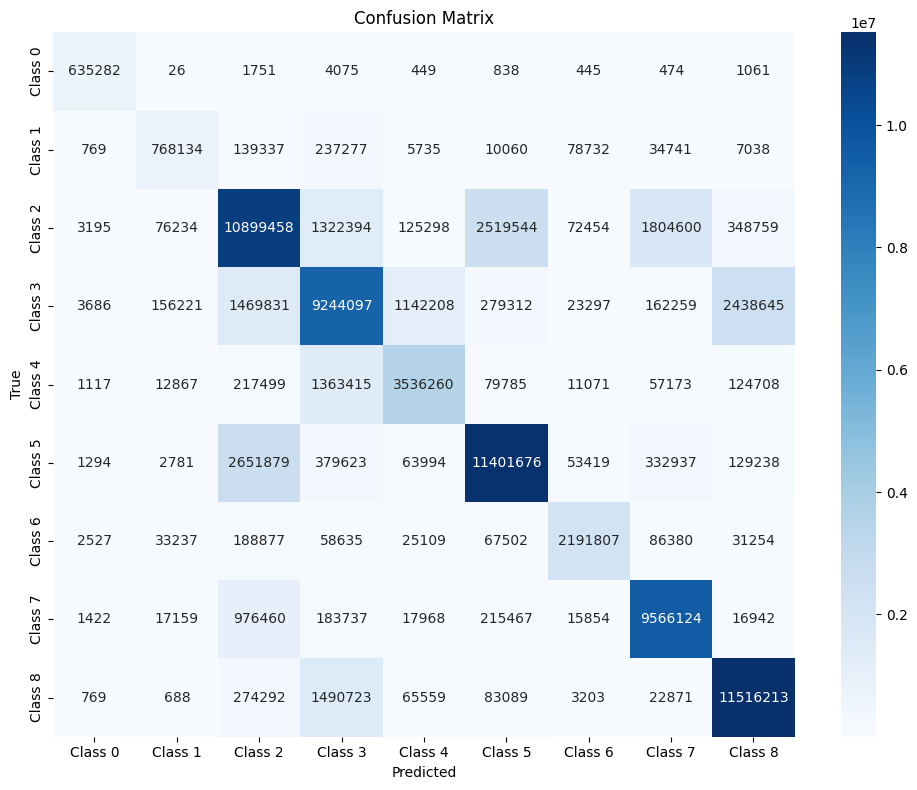


📊 SEGMENTATION METRICS
Overall Accuracy     : 0.7324
Average Accuracy     : 0.7549
Mean IoU (mIoU)      : 0.6303
FWIoU                : 0.5831
Mean Dice            : 0.7625
Precision (macro)    : 0.7728
Recall (macro)       : 0.7549
F1-score (macro)     : 0.7625
Kappa Coefficient    : 0.6802

📌 PER-CLASS METRICS
--------------------------------------
Class 0:
  IoU       : 0.9637
  Dice      : 0.9815
  Accuracy  : 0.9858
  Precision : 0.9773
  Recall    : 0.9858
  F1 Score  : 0.9815
--------------------------------------
Class 1:
  IoU       : 0.4858
  Dice      : 0.6540
  Accuracy  : 0.5993
  Precision : 0.7197
  Recall    : 0.5993
  F1 Score  : 0.6540
--------------------------------------
Class 2:
  IoU       : 0.4720
  Dice      : 0.6413
  Accuracy  : 0.6347
  Precision : 0.6480
  Recall    : 0.6347
  F1 Score  : 0.6413
--------------------------------------
Class 3:
  IoU       : 0.4631
  Dice      : 0.6331
  Accuracy  : 0.6196
  Precision : 0.6472
  Recall    : 0.6196
  F1 Score

In [37]:
import numpy as np
import torch
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, cohen_kappa_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

num_classes = 9
class_names = [f"Class {i}" for i in range(num_classes)]

# ============================
# 1️⃣ COLLECT PREDICTIONS & LABELS
# ============================
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, masks in val_loader:
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1)

        all_preds.append(preds.cpu().numpy().reshape(-1))
        all_labels.append(masks.cpu().numpy().reshape(-1))

# Concatenate lists into single arrays
y_true = np.concatenate(all_labels).astype(int)
y_pred = np.concatenate(all_preds).astype(int)

# Keep only valid labels
mask_valid = (y_true >= 0) & (y_true < num_classes)
y_true = y_true[mask_valid]
y_pred = y_pred[mask_valid]

print("Pixels evaluated:", len(y_true))

# ============================
# 2️⃣ CONFUSION MATRIX
# ============================
cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
print("\nConfusion Matrix:\n", cm)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# ============================
# 3️⃣ IoU, mIoU, Dice, FWIoU
# ============================
intersection = np.diag(cm).astype(np.float64)
gt_set = cm.sum(axis=1).astype(np.float64)
pred_set = cm.sum(axis=0).astype(np.float64)
union = gt_set + pred_set - intersection

# Per-class IoU
IoU = np.zeros(num_classes, dtype=np.float64)
valid_union = union > 0
IoU[valid_union] = intersection[valid_union] / union[valid_union]
mIoU = np.nanmean(IoU[valid_union]) if valid_union.any() else np.nan

# Per-class Dice
Dice = np.zeros(num_classes, dtype=np.float64)
sum_regs = pred_set + gt_set
valid_sum = sum_regs > 0
Dice[valid_sum] = (2.0 * intersection[valid_sum]) / sum_regs[valid_sum]
meanDice = np.nanmean(Dice[valid_sum]) if valid_sum.any() else np.nan

# Frequency Weighted IoU
freq = gt_set / gt_set.sum() if gt_set.sum() > 0 else np.zeros_like(gt_set)
FWIoU = (freq[valid_union] * IoU[valid_union]).sum()

# ============================
# 4️⃣ ACCURACY
# ============================
per_class_acc = np.zeros(num_classes, dtype=np.float64)
per_class_acc[gt_set > 0] = intersection[gt_set > 0] / gt_set[gt_set > 0]
avg_acc = np.nanmean(per_class_acc[gt_set > 0]) if (gt_set > 0).any() else np.nan
overall_acc = intersection.sum() / cm.sum() if cm.sum() > 0 else np.nan

# ============================
# 5️⃣ PRECISION, RECALL, F1
# ============================
precision_per_class, recall_per_class, f1_per_class, _ = precision_recall_fscore_support(
    y_true, y_pred, labels=list(range(num_classes)), zero_division=0
)

precision_macro = precision_per_class.mean()
recall_macro = recall_per_class.mean()
f1_macro = f1_per_class.mean()

# ============================
# 6️⃣ COHEN'S KAPPA
# ============================
kappa = cohen_kappa_score(y_true, y_pred)

# ============================
# 7️⃣ PRINT SUMMARY
# ============================
print("\n==============================")
print("📊 SEGMENTATION METRICS")
print("==============================")
print(f"Overall Accuracy     : {overall_acc:.4f}")
print(f"Average Accuracy     : {avg_acc:.4f}")
print(f"Mean IoU (mIoU)      : {mIoU:.4f}")
print(f"FWIoU                : {FWIoU:.4f}")
print(f"Mean Dice            : {meanDice:.4f}")
print(f"Precision (macro)    : {precision_macro:.4f}")
print(f"Recall (macro)       : {recall_macro:.4f}")
print(f"F1-score (macro)     : {f1_macro:.4f}")
print(f"Kappa Coefficient    : {kappa:.4f}")
print("==============================\n")

# ========= Per-Class Breakdown =========
print("📌 PER-CLASS METRICS")
print("--------------------------------------")
for i in range(num_classes):
    print(f"{class_names[i]}:")
    print(f"  IoU       : {IoU[i]:.4f}")
    print(f"  Dice      : {Dice[i]:.4f}")
    print(f"  Accuracy  : {per_class_acc[i]:.4f}")
    print(f"  Precision : {precision_per_class[i]:.4f}")
    print(f"  Recall    : {recall_per_class[i]:.4f}")
    print(f"  F1 Score  : {f1_per_class[i]:.4f}")
    print("--------------------------------------")
